## Assignment 2 - Data Analysis - Web Mining

The web is an immense source of data, offering valuable insights across various domains. In this assignment, we will explore different ways to process, and analyze web data to uncover meaningful patterns and make informed decisions. Through five practical exercises, we will apply key data mining techniques to real-world scenarios.

Each exercise focuses on a specific application:

* *Exercise 1* - Clickbait classification
* *Exercise 2* - Sentiment analysis on comments
* *Exercise 3* - Movie recommendation
* *Exercise 4* - Association rules in online shopping
* *Exercise 5* - Clustering of mobile apps

These exercises will provide hands-on experience in working with real-world data collected from the web, helping you understand its potential for analysis.

For this assignment, complete all exercises that are marked in <span style='color:red;font-weight:bold'>red</span>. Please make sure all your cells run correctly (try to *Clear All Outputs* then *Run All* once before submitting). **Check the cells outputs are visibles even for the coding parts**

The assignment is due for <span style='color:red;font-weight:bold'>Thursday 26th of March 2026 at 23:59</span>.

No report is needed as all questions can be answered directly in this notebook file. You only need to give this notebook file completed on the [Moodle assignment page](https://moodle.msengineering.ch/mod/assign/view.php?id=229885). Only one file per group is required for submission.

If you have any questions or issues, please contact one of the assistants below:
- Cédric Campos Carvalho (*Teams* might be easier to discuss, mail: cedric.camposcarvalho@heig-vd.ch)
- Elena Najdenovska (mail: elena.najdenovska@heig-vd.ch)


Teacher : 
- Laura Elena Raileanu <Laura.Raileanu@heig-vd.ch>(mail: Laura.Raileanu@heig-vd.ch)

Students:
- Agodomou Christian
- Hertling Nicolas
- Lavorel Loïc

### Exercise 1 - Clickbait classification

The objective of this first part is to model a filter for "clickbait" in online news media. Clickbait headlines are designed to attract attention and drive clicks, often at the expense of accuracy or relevance.

To achieve this, we provide you with a dataset containing more than 10'000 press headlines collected in 2016. Each row in this dataset corresponds to a single headline, which is described by the following two attributes:

* `headline`: the text representing the title
* `clickbait`: the label identifying whether the title is a clickbait *(1)* or not *(0)*.

In [89]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC



import warnings
warnings.simplefilter("ignore")

In [90]:
df_1 = pd.read_excel('data/part1_classification/news_clickbait.xlsx', engine="openpyxl")
df_1

,headline,clickbait
0,You Need To Tell Us If These Things Are Doughnuts,1
1,15 Great Pieces Of Relationship Advice From Books,1
2,Improved E-Mail Service From a Dedicated Device,0
3,"Two MBTA Green Line trains collide in Newton, ...",0
4,17 Struggles All Smartypants Will Understand,1
...,...,...
10536,Can You Match The Phone To The R&B Video,1
10537,19 Soul Food Recipes That Are Almost As Good A...,1
10538,16 Photos Of Desis That Will Give You Intense ...,1
10539,City Plans to Make Older Buildings Refit to Sa...,0


<p style='color:red;font-weight:bold'>Exercise 1.1 :</p>

The first step is to separate the dataset into two sets (training and test), complete the input parameters of `train_test_split` function.

In [91]:
X = df_1['headline']
y = df_1['clickbait']

result = train_test_split(X, y, test_size=0.2, random_state=42)

<p style='color:red;font-weight:bold'>Exercise 1.2 :</p>

Create a pre-processing `Pipeline` using [scikit-learn Pipeline object](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html).
In your pipeline you need:
- Vectorize your headlines with Term frequency-inverse document frequency.
- Transform your data in case of [`sparse matrix`](https://docs.scipy.org/doc/scipy/reference/sparse.html#module-scipy.sparse), so the data goes through the model without any issues.

**Do not forget to remove words giving no information for classification (i.e. [stop words](https://en.wikipedia.org/wiki/Stop_word)).**

In [92]:
preprocessor = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")), 
    ("to_dense", FunctionTransformer(lambda x: x.toarray(), accept_sparse=True))  
])

<p style='color:red;font-weight:bold'>Exercise 1.3 :</p>

Create the pipeline using `make_pipeline`, combining the pre-processing pipeline and the `GaussianNB` model. Then, train the pipeline and find the score obtained with the test set.

In [93]:
# TODO 1.3
X_train, X_test, y_train, y_test = result
# Pipeline complet
pipeline = make_pipeline(
    preprocessor,
    GaussianNB()
)

# Entraînement
pipeline.fit(X_train, y_train)

# Prédiction et score
y_pred = pipeline.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.89900426742532


<p style='color:red;font-weight:bold'>Exercise 1.4 :</p>

Modify your split ratio for the training/testing set and see if there's a difference in the model's performances. Please explain your findings.

*TODO 1.4*
There is not much difference when changing the split ratio, the accuracy stays pretty much the same when going from 0.2 to 0.5. THis could be explained by the fact that our data is homogenous and representative.

<p style='color:red;font-weight:bold'>Exercise 1.5 :</p>

Keep your split validation but now incorporate [cross validation](https://en.wikipedia.org/wiki/Cross-validation_(statistics)). Use the [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) function and a K-Folding with 5 splits over the training set without using the test set. Then, calculate the averaged accuracy (with standard deviation) for 5 folds.

**Explain the results obtained and how to read them compared to the split validation.**

In [94]:
# TODO 1.5µ
print("Accuracy:", np.mean(y_pred == y_test))

scores = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
mean_acc = scores.mean()
std_acc = scores.std()
print("Cross-validation scores:", scores)
print("Mean accuracy:", mean_acc)
print("Standard deviation:", std_acc)

Accuracy: 0.89900426742532
Cross-validation scores: [0.90042674 0.89184061 0.89041746 0.88994307 0.88519924]
Mean accuracy: 0.8915654244077296
Standard deviation: 0.0049613874092948596


*TODO 1.5*

In this instance cross validation gives us a more accurate value of how much our model is performing.
We can see that our accuracy is really close to our cross validation which means that our model is stable across different data split

<p style='color:red;font-weight:bold'>Exercise 1.6 :</p>

Try to use atleast 3 different classifiers and report their results in a table. Compare the results between them.

In [95]:
# TODO 1.6
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC()
}

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ("vectorizer", TfidfVectorizer()),
        ("classifier", model)
    ])
    
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
    
    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std": scores.std()
    })

df_results = pd.DataFrame(results)
print(df_results)

                Model  Mean Accuracy       Std
0       MultinomialNB       0.955526  0.004806
1  LogisticRegression       0.950664  0.003802
2           LinearSVC       0.962642  0.001190


*TODO 1.6*

<p style='color:red;font-weight:bold'>Exercise 1.7 :</p>

In text processing we often use a stemming step for the pre-processing, explain what it consists and how it can be useful then give an example.

*TODO 1.7*

Stemming is a technique used when we want to normalise our text. If we have for example the two words "Working" and "Worker", after stemming them they'd be reduced to "Work". With this we can reduce the dimensionnality of our text which gives us a better processing time. 

### Exercise 2 - Sentiment analysis on comments

The goal of the second part is to analyze tweets from the COVID-19 period and perform sentiment analysis to determine whether they express a positive or negative sentiment.

In the first step, we will work with the dataset `CoronaTwitterComments_2labels.xlsx`, which contains approximately 3'000 comments related to COVID-19 from Twitter in March 2020. These comments are already labeled with *1* (positive comment) or *-1* (negative comment). In the second step, we will consider the dataset `CoronaTwitterComments_3labels.xlsx`, which includes additional neutral comments (labeled with *0*). You will see how we can process the text data with the help of [WordNet](https://wordnet.princeton.edu/) to retrieve a sentiment and evaluate the results.

In [96]:
%pip install nltk

from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

import nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [97]:
# NLTK packages needed for this exercise, feel free to add some if you need it.

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('sentiwordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LocalAdmin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LocalAdmin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\LocalAdmin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package sentiwordnet to
[nltk_data]     C:\Users\LocalAdmin\AppData\Roaming\nltk_data...
[nltk_data]   Package sentiwordnet is already up-to-date!


True

In [98]:
corona_tweets2 = pd.read_excel('data/part2_sentimentanalysis/CoronaTwitterComments_2labels.xlsx', engine="openpyxl")
corona_tweets3 = pd.read_excel('data/part2_sentimentanalysis/CoronaTwitterComments_3labels.xlsx', engine="openpyxl")

print(corona_tweets2.SentimentLabel.unique(), corona_tweets3.SentimentLabel.unique())
corona_tweets2

[-1  1] [-1  1  0]


,OriginalTweet,SentimentLabel
0,TRENDING: New Yorkers encounter empty supermar...,-1
1,When I couldn't find hand sanitizer at Fred Me...,1
2,Find out how you can protect yourself and love...,1
3,#Panic buying hits #NewYork City as anxious sh...,-1
4,Voting in the age of #coronavirus = hand sanit...,1
...,...,...
3174,"@RicePolitics @MDCounties Craig, will you call...",-1
3175,Meanwhile In A Supermarket in Israel -- People...,1
3176,Did you panic buy a lot of non-perishable item...,-1
3177,Gov need to do somethings instead of biar je r...,-1


<p style='color:red;font-weight:bold'>Exercise 2.1 :</p>

The first step is to pre-process the text (like in previous exercise) to later use a WordNet sentiment analysis over it.

The class inherits from `BaseEstimator` and `TransformerMixin`, ensuring seamless integration with other scikit-learn modules. This allows it to utilize the familiar `fit`, `transform`, and `fit_transform` functions of the library.

Your task is to update the `NLTKPreprocessor` class with the needed functions to be used later in the `transform` function.
- Add a tokenizer specialized in tweets.
- Remove stop words and other unuseful characters.
- Transform in lowercase the text
- Lemmatize the text using for Wordnet.

*Advice : If you encounter any issues, refer to the `apply_pipeline` function to understand how it works. This function should **not** be modified.*

In [99]:
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

class NLTKPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        # TODO        
        self.stop_words = set(stopwords.words("english"))
        self.lemmatizer = WordNetLemmatizer()
        self.tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
        
        
        self.pipeline = [
            # TODO
            self.tokenizer.tokenize,
            lambda tokens: [t for t in tokens if t.isalpha() and t not in self.stop_words],
            lambda tokens: [self.lemmatizer.lemmatize(t) for t in tokens],
        ]
    def apply_pipeline(self, x):
        for transform in self.pipeline:
            x = transform(x)
        return x


    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [self.apply_pipeline(x) for x in X]

<p style='color:red;font-weight:bold'>Exercise 2.2 :</p>

The next step is to create the `WordNetSentimentAnalyzer`. You will need to create three functions to add to your pipeline : 
1. The WordNet sentiment analysis requires to have the tag of each word of the sentence. Tagging in part of speech (POS) is the process of assigning grammatical categories, such as nouns, verbs, or adjectives, to words in a text based on their role in a sentence. `nltk` has a pre-trained model that can tag these words, find it and apply it to the pipeline.
2. For WordNet the tagging is different from the pre-trained `nltk` model. Create a function replacing the tags with the WordNet tags using `nltk.corpus.wordnet` module.
3. Create the sentiment function which sums the positive sentiment ($\text{pos}$) and negative sentiment ($\text{neg}$) of each word (using `nltk.corupus.sentiwordnet` module). The value needs to be taken in account only if it is superior to a certain threshold (i.e. $\text{treshold} = 0.05$). Then, return a single value representing the sentiment of the sentence such as it is $\text{sentiment} < 0$ if it's negative and $\text{sentiment} > 0$ if positive.


In [100]:
from nltk import pos_tag
from nltk.corpus import wordnet, sentiwordnet as swn

class WordNetSentimentAnalyzer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # TODO

        self.threshold = 0.05

        def convert_to_wn_tags(tagged_tokens):
            tag_map = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'N': wordnet.NOUN, 'R': wordnet.ADV}
            return [(word, tag_map.get(tag[0], wordnet.NOUN)) for word, tag in tagged_tokens]

        def get_sentiment(tagged_tokens):
            sentiment = 0
            for word, tag in tagged_tokens:
                synsets = list(swn.senti_synsets(word, tag))
                if synsets:
                    score = synsets[0].pos_score() - synsets[0].neg_score()
                    if abs(score) > self.threshold:
                        sentiment += score
            return sentiment

        self.pipeline = [
            pos_tag,
            convert_to_wn_tags,
            get_sentiment,
        ]

    def apply_pipeline(self, x):
        for transform in self.pipeline:
            x = transform(x)
        return x
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return [self.apply_pipeline(x) for x in X]

<p style='color:red;font-weight:bold'>Exercise 2.3 :</p>

Create two functions that return the sentiment class to compare it to the labels.
* `get_sentiment_class_2` : For positive and negative only.
* `get_sentiment_class_3` : For positive, negative and neutral.

**Do not forget that it is going to be used in a `scikit-learn` `Pipeline`!**

In [101]:
def get_sentiment_class_2(sent_val):
    return 1 if sent_val > 0 else 0

def get_sentiment_class_3(sent_val):
    if sent_val > 0:
        return 1
    elif sent_val < 0:
        return -1
    else:
        return 0
    

<p style='color:red;font-weight:bold'>Exercise 2.4 :</p>

Create a `scikit-learn` `Pipeline` using the 3 previous *Transformers* that you created (using the 2 class sentiment).

Then, complete the function `get_sentiment_tweet` and test it with your own Tweet (**Do not change its signature !**).

In [102]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np

pipeline = Pipeline(steps=[
    # TODO
    ("preprocessor", NLTKPreprocessor()),
    ("analyzer", WordNetSentimentAnalyzer()),
    ("classifier", FunctionTransformer(np.vectorize(get_sentiment_class_2)))
])

def get_sentiment_tweet(tweet:str)-> int:
    return pipeline.transform([tweet])[0]

# TODO

print(get_sentiment_tweet("I love this vaccine, feeling great!"))
print(get_sentiment_tweet("This pandemic is terrible and scary"))

1
0


<p style='color:red;font-weight:bold'>Exercise 2.5 :</p>

Compute the accuracy obtained with all tweets of the dataset. Then, do the same for the 3 labels class.

In [103]:
# TODO 2.5

y_pred_2 = pipeline.transform(corona_tweets2['OriginalTweet'])
acc_2 = np.mean(y_pred_2 == corona_tweets2['SentimentLabel'])
print("Accuracy 2 labels:", acc_2)

pipeline_3 = Pipeline(steps=[
    ("preprocessor", NLTKPreprocessor()),
    ("analyzer", WordNetSentimentAnalyzer()),
    ("classifier", FunctionTransformer(np.vectorize(get_sentiment_class_3)))
])

y_pred_3 = pipeline_3.transform(corona_tweets3['OriginalTweet'])
acc_3 = np.mean(y_pred_3 == corona_tweets3['SentimentLabel'])
print("Accuracy 3 labels:", acc_3)

Accuracy 2 labels: 0.3441333752752438
Accuracy 3 labels: 0.5573986308583465


<p style='color:red;font-weight:bold'>Exercise 2.6 :</p>

Analyze the results of each pre-processing (`NLTKPreprocessor`) step to try to understand what you could do to improve it. For example, what could you add into this pipeline ? *(No implementation needed)*

## Answer 
The current result are worst than a random classifier. An explanation for that would be the fact that some info from our data is not relevant in what we are looking to do. URLs, hashtags and mentions (@user) are not removed and pollute our analysis. 

### Exercise 3 - Movie recommendation

The objective of this exercise is to create a recommendation system of movies based on the user ratings. We will focus on the collaborative approach for movie recommendation using the provided dataset, which contains approximately 9'800 movies rated by 610 users from MovieLens.

More specifically, the `movies.csv` dataset, which describes the movies, includes three attributes:

* `movieId`: unique identifier of the movie
* `title`: the title of the movie (with the release year in parentheses)
* `genres`: the genres of the movie

The `ratings.csv` dataset, which contains user ratings for the movies, includes four attributes:

* `userId`: unique identifier of the user
* `movieId`: unique identifier of the movie
* `rating`: the user's rating for the corresponding movie
* `timestamp`: the timestamp of the rating

In [104]:
from sklearn.neighbors import NearestNeighbors
import pandas as pd


In [105]:
df_movies = pd.read_csv('data/part3_recommandationdesfilms/movies.csv')
df_ratings = pd.read_csv('data/part3_recommandationdesfilms/ratings.csv')

df_3 = pd.merge(df_movies, df_ratings, on='movieId')
df_3

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483
...,...,...,...,...,...,...
100831,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,184,4.0,1537109082
100832,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,184,3.5,1537109545
100833,193585,Flint (2017),Drama,184,3.5,1537109805
100834,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,184,3.5,1537110021


<p style='color:red;font-weight:bold'>Exercise 3.1 :</p>

Use `df_3` to create a second `DataFrame` with the rating of every movies for each `userId`. If the user never watched a movie the value is $0$. 
For this step, use the [`pivot` function](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pivot.html).

In [106]:
user_item_matrix = df_3.pivot(index='userId', columns='movieId', values='rating').fillna(0)
X = user_item_matrix.to_numpy()
X

array([[4. , 0. , 4. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [2.5, 2. , 2. , ..., 0. , 0. , 0. ],
       [3. , 0. , 0. , ..., 0. , 0. , 0. ],
       [5. , 0. , 0. , ..., 0. , 0. , 0. ]], shape=(610, 9724))

<p style='color:red;font-weight:bold'>Exercise 3.2 :</p>

First separate the data using `train_test_split` function with $20\%$ of the data in the test set.
Create an `knn` model using the [`NearestNeighbors`](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors) model from `scikit-learn`. For now use $N=80$, and the `cosine` metric, then train it.

**Explain in few sentences how does the `cosine` metric works by taking our case in an example (include the formula).**

In [107]:
indices = np.arange(len(X))
ds_train, ds_test, idx_train, idx_test = train_test_split(X, indices, random_state=42, test_size=20)

knn = NearestNeighbors(n_neighbors=80, metric='cosine')

knn.fit(ds_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",80
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


##### Cosine :
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_distances.html#sklearn.metrics.pairwise.cosine_distances

La métrique "cosinus" mesure l'angle entre deux vecteurs (les profils de deux utilisateurs) plutôt que la distance "en ligne droite" (comme la distance eucliedian). La distance cosinus est définie comme 1,0 moins la similarité cosinus et la similarité on la calcule avec la formule suivante.
###### Formule :
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html#sklearn.metrics.pairwise.cosine_similarity
$$\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$$

<p style='color:red;font-weight:bold'>Exercise 3.3 :</p>

Create the `predict` function by using the previous trained model.

*Hints : Think about the model returns and what they represent. Then, use the closest indexes to obtain information on the best matching movies.* 

In [108]:
def predict(X, user_item_matrix, knn):
    distances, indices = knn.kneighbors(X)
    predictions = []
    for i in range(len(X)):
        neighbor_indices = indices[i]
        neighbor_ratings = user_item_matrix.iloc[neighbor_indices]
        user_prediction = neighbor_ratings.mean(axis=0)
        predictions.append(user_prediction)
    return pd.DataFrame(predictions, columns=user_item_matrix.columns)



<p style='color:red;font-weight:bold'>Exercise 3.4 :</p>

Finally, complete the `prec_at_k` function, which measures the precision of our model. This metric calculates how many of the top $k$ movies recommended to a user are actually relevant. A movie is considered relevant if the user has given it a score of at least 4..

In [109]:
def prec_at_k(Y_pred, user_item_matrix, k, Y_idx):
    precisions = []
    for i in range(len(Y_pred)):
        user_preds = Y_pred.iloc[i]
        top_k_movies = user_preds.sort_values(ascending=False).head(k).index
        actual_user_id = Y_idx[i]
        actual_ratings = user_item_matrix.iloc[actual_user_id].loc[top_k_movies]
        relevant_count = (actual_ratings >= 4).sum()
        precisions.append(relevant_count / k)
    return np.mean(precisions)

<p style='color:red;font-weight:bold'>Exercise 3.5 :</p>

Now, use the function with three different values for k ($5$, $15$, $25$) each time. Then, use different $N$ neighbours and a different split ratio.

Report all your results bellow and explain the impact of these hyperparameters in the model.

In [110]:
# TODO 3.5
Ks = [5, 15, 25]
Ratios = [15, 25, 30]
Nn = [5, 25, 50, 80]


for n in Nn:
    for r in Ratios:
        indices = np.arange(len(X))
        ds_train, ds_test, idx_train, idx_test = train_test_split(X, indices, random_state=42, test_size=r)
        knn = NearestNeighbors(n_neighbors=n, metric='cosine')
        knn.fit(ds_train)
        Y_pred = predict(ds_test, user_item_matrix, knn)
        for k in Ks:
            print(f"Prediction result for {k} movies prediction {n} Neighbors and ratio {r}% : {prec_at_k(Y_pred, user_item_matrix, k, idx_test)}" )
    print("------")


Prediction result for 5 movies prediction 5 Neighbors and ratio 15% : 0.42666666666666675
Prediction result for 15 movies prediction 5 Neighbors and ratio 15% : 0.32000000000000006
Prediction result for 25 movies prediction 5 Neighbors and ratio 15% : 0.28800000000000003
Prediction result for 5 movies prediction 5 Neighbors and ratio 25% : 0.4
Prediction result for 15 movies prediction 5 Neighbors and ratio 25% : 0.2826666666666667
Prediction result for 25 movies prediction 5 Neighbors and ratio 25% : 0.2528
Prediction result for 5 movies prediction 5 Neighbors and ratio 30% : 0.3
Prediction result for 15 movies prediction 5 Neighbors and ratio 30% : 0.2577777777777778
Prediction result for 25 movies prediction 5 Neighbors and ratio 30% : 0.22533333333333336
------
Prediction result for 5 movies prediction 25 Neighbors and ratio 15% : 0.4933333333333333
Prediction result for 15 movies prediction 25 Neighbors and ratio 15% : 0.43555555555555553
Prediction result for 25 movies prediction

#### Ratio
Nous pouvons d'abord observer que le ratio de 15% est dans chaque cas les meilleurs résultats et que plus on augmente plus nous avons des résultats de moins bonne qualité. Donc, dans notre cas, c'est le meilleur ratio à prendre.

#### N voisins
Concernant le nombre de voisins, nous pouvons observer que plus on augmente ce nombre, plus l'accuracy s'améliore, jusqu'à atteindre un pic à 50 où l'on obtient le meilleur score. Cela est sûrement du car ce seuil est suffisant pour éviter que le bruit n'ait un impact trop important, sans pour autant être trop élevé, ce qui risquerait de "demander l'avis" a des gens qui ne nous ressemble moins.

#### K Films
Comme toute attente plus on demande de films plus nous avons de moins bons résultats, car il a plus de chance de se tromper et surtout que certains utilisateurs n'a potentiellement pas mis plus de 25 films a 4 étoiles.

#### Conclusion
Pour conclure, le meilleur réglage est de 50 voisins avec un ratio de 15 %. On parvient ainsi à prédire un résultat correct dans environ 50 % des cas, ce qui est une très bonne performance puisque nous exigeons une note de 4 pour qu'un film soit considéré comme pertinent. En faisant des tests, si nous descendons ce critère de pertinence à une note de 3, nous atteignons 70 % d'accuracy.


### Exercise 4 - Association rules in online shopping

In this fourth part, we will focus on a **Market Basket Analysis** problem. The dataset provided contains **online sales transactions** from an e-commerce site over one year. Our goal is to generate **association rules** based on these sales to identify which items are frequently bought together. You can refer to the source mentioned in the **README file** included with the data for more details.  

The dataset is structured as follows, with each row representing the details of a product sale:  
- `InvoiceNo`: invoice/sale identifier  
- `StockCode`: product identifier  
- `Description`: purchased product  
- `Quantity`: quantity sold  
- `InvoiceDate`: order/payment date  
- `UnitPrice`: price of the product  
- `CustomerID`: customer identifier  
- `Country`: customer’s country of residence

In [111]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

In [112]:
df_4 = pd.read_excel('data/part4_marketbasketanalysis/OnlineRetailDataset.xlsx', engine='openpyxl')
df_4

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
397919,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France
397920,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France
397921,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France
397922,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France


<p style='color:red;font-weight:bold'>Exercise 4.1 :</p>

Transform the given dataset into a one-hot encoded format for association rule mining. Group items by customer so that each row represents a unique customer with a list of purchased items. Then, convert this into a binary matrix where each column is an item, and values indicate whether a customer bought that item (1) or not (0). Use [`MultiLabelBinarizer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html) to achieve this.

In [113]:
df_4_clean = df_4.dropna(subset=['CustomerID','Description']).copy()

customer_items = (
    df_4_clean.groupby('CustomerID')['Description']
    .apply(list)
    .reset_index()
)
print(customer_items.head())

#one-hot encoding
mlb = MultiLabelBinarizer()
one_hot = pd.DataFrame(
    mlb.fit_transform(customer_items['Description']),
    columns=mlb.classes_,
    index=customer_items['CustomerID']
)

one_hot = one_hot.reset_index()
print(one_hot.head())
print(one_hot.shape)


   CustomerID                                        Description
0       12346                   [MEDIUM CERAMIC TOP STORAGE JAR]
1       12347  [BLACK CANDELABRA T-LIGHT HOLDER, AIRLINE BAG ...
2       12348  [72 SWEETHEART FAIRY CAKE CASES, 60 CAKE CASES...
3       12349  [PARISIENNE CURIO CABINET, SWEETHEART WALL TID...
4       12350  [CHOCOLATE THIS WAY METAL SIGN, METAL SIGN NEI...
   CustomerID   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
0       12346                               0                               0   
1       12347                               0                               0   
2       12348                               0                               0   
3       12349                               0                               0   
4       12350                               0                               0   

    DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
0                   0                             0   
1            

<p style='color:red;font-weight:bold'>Exercise 4.2 :</p>

Finally, create the association rules based on the frequent patterns obtained through `FP-growth` algorithm. Check [`mlxtend`](https://rasbt.github.io/mlxtend/) documentation to complete this task. Then, show what are the association rules with a minimum of $0.9$ confidence.

In [114]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

basket = one_hot.set_index('CustomerID').astype(bool) #I had a warning explaining that mlxtend prefers True/False than 0/1 -> astype(bool)
#found frequent items
frequent_itemsets = fpgrowth(
    basket,
    min_support=0.05,
    verbose=False
)

print(frequent_itemsets.head())

#gen association rules
rules = (association_rules
     (
        frequent_itemsets,
        metric="confidence",
        min_threshold=0.9
    ))
print(rules.shape)
print(rules.head())

    support           itemsets
0  0.203042  frozenset({2767})
1  0.103711  frozenset({2656})
2  0.097488  frozenset({2865})
3  0.095414   frozenset({109})
4  0.089422   frozenset({147})
(5, 14)
                     antecedents        consequents  antecedent support  \
0              frozenset({2527})  frozenset({1509})            0.073519   
1        frozenset({2865, 2527})  frozenset({1509})            0.062687   
2        frozenset({2767, 2527})  frozenset({1509})            0.059691   
3  frozenset({2865, 2767, 2527})  frozenset({1509})            0.053699   
4  frozenset({2767, 1509, 2527})  frozenset({2865})            0.056465   

   consequent support   support  confidence       lift  representativity  \
0            0.089191  0.068218    0.927900  10.403506               1.0   
1            0.089191  0.060152    0.959559  10.758464               1.0   
2            0.089191  0.056465    0.945946  10.605838               1.0   
3            0.089191  0.051625    0.961373  10.778

<p style='color:red;font-weight:bold'>Exercise 4.3 :</p>

Do you observe any changes in the different parameters of the *FP-Growth* and *Association Rules* functions ? Please comment on the chosen parameters and the results obtained.

## For the FP-Growth parameters :

We use min_support = 0.05. This means only itemsets appearing in at least 5% of customers are kept.

Compared to a smaller value (for example 0.01), there will be fewer frequent itemsets, reduces computation time, generates more meaningful and general patterns. A lower min_support (for example 0.01), will produce many more frequent itemsets, generates a very large number of rules, increases computation tima and may produce less meaningful rules. Using 0.05 as min_support, we focus on more common purchasing patterns, which improves interpretability.

## For Association Rules parameters :

We use metric="confidence" and min_threshold=0.9. This means only rules with confidence >= 90% are kept. This ensures strong relationships between products and keep only strong and reliable rules. If we used a lower threshold, we should obtain more rules, but some of them might be less meaningful or less reliable. Therefore, chosing a high confidence value helps reduce noise and focuse on the most relevant associations.


<p style='color:red;font-weight:bold'>Exercise 4.4 :</p>

Is it possible to use other column(s) from the initial data to generate interesting rules?

Yes, other column such as Country, InvoiceNo or InvoiceDate can be used to generate more interesting rules. Grouping by invoiceNo allows analyzing products bought in the same transaction, which is more relevant for market basket analysis. Using country allows discovering geographical buying patterns. Using invoicedate enables seasonal analysis, such as identifying products frequently bought during holidays or season.

### Exercise 5 - Clustering of mobile apps

In this final part, we will perform clustering of applications from the Google Play Store. You can refer to the source mentioned in the **README file** included with the data for more details.

Among the attributes available in the `googleplaystore.xlsx` file, we will use the following:

* `Rating`: overall user rating of the application
* `Reviews`: number of user reviews
* `Size`: size of the application
* `Installs`: number of users who installed the application
* `Price`: price of the application



In [115]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [116]:
df_5 = pd.read_excel('data/part5_clustering/googleplaystore.xlsx', engine='openpyxl')
df_5

,Rating,Reviews,Size,Installs,Price,App,Category
0,4.1,159,19.0,10000,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN
1,3.9,967,14.0,500000,0,Coloring book moana,ART_AND_DESIGN
2,4.7,87510,8.7,5000000,0,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN
3,4.5,215644,25.0,50000000,0,Sketch - Draw & Paint,ART_AND_DESIGN
4,4.3,967,2.8,100000,0,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN
...,...,...,...,...,...,...,...
9361,4.0,7,2.6,500,0,FR Calculator,FAMILY
9362,4.5,38,53.0,5000,0,Sya9a Maroc - FR,FAMILY
9363,5.0,4,3.6,100,0,Fr. Mike Schmitz Audio Teachings,FAMILY
9364,4.5,114,0.0,1000,0,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE


<p style='color:red;font-weight:bold'>Exercise 5.1 :</p>

Select the numerical features of the dataset then standardize them by removing the mean and scaling to unit variance. 
Then, do a first training using [`KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) algorithm with $5$ clusters.

In [117]:
# TODO 5.1
features = ['Rating', 'Reviews', 'Size', 'Installs', 'Price']
df_r = df_5[features]
name = df_5['App']
# Standartisation (https://www.geeksforgeeks.org/python/how-to-standardize-data-in-a-pandas-dataframe/)
sc = StandardScaler()
df_s = sc.fit_transform(df_r)

km = KMeans(n_clusters=5, random_state=42, max_iter=1, n_init=1).fit(df_s)


<p style='color:red;font-weight:bold'>Exercise 5.2 :</p>

Complete the function `average_cluster_distance` to compute a clustering performance metric. It should return a list where the first value is the global average distance from all samples to their assigned centroids, followed by the average distances per centroid. 

In [118]:
def average_cluster_distance(X, model):
    distances_to_all = model.transform(X)
    labels = model.labels_
    assigned_distances = distances_to_all[np.arange(len(labels)), labels]
    global_avg = np.mean(assigned_distances)
    per_cluster_avg = []
    for i in range(model.n_clusters):
        dist_i = assigned_distances[labels == i]
        per_cluster_avg.append(np.mean(dist_i) if len(dist_i) > 0 else 0)

    return [global_avg, per_cluster_avg]

avg_distances = average_cluster_distance(df_s, km)
print(avg_distances)

[np.float64(0.7864124146220386), [np.float64(0.592898499801863), np.float64(0.7767756778022116), np.float64(5.452424510711298), np.float64(2.0611979775098903), np.float64(2.1687829057845316)]]


<p style='color:red;font-weight:bold'>Exercise 5.3 :</p>

Try using different values for the maximum number of iterations of the *K-Means Algorithm*. Then, report your results and describe them.

In [119]:
# TODO 5.3
iterations = [1, 2, 5, 10, 20, 100, 200, 1000]
results = []

for i in iterations:
    km = KMeans(n_clusters=5, max_iter=i, random_state=42, n_init=1).fit(df_s)
    avg_dist = average_cluster_distance(df_s, km)[0]
    results.append(avg_dist)
    print(f"Max Iter: {i}, Iter : {km.n_iter_} -> Distance Moyenne: {avg_dist:.4f}")

Max Iter: 1, Iter : 1 -> Distance Moyenne: 0.7864
Max Iter: 2, Iter : 2 -> Distance Moyenne: 0.7726
Max Iter: 5, Iter : 5 -> Distance Moyenne: 0.7621
Max Iter: 10, Iter : 8 -> Distance Moyenne: 0.7649
Max Iter: 20, Iter : 8 -> Distance Moyenne: 0.7649
Max Iter: 100, Iter : 8 -> Distance Moyenne: 0.7649
Max Iter: 200, Iter : 8 -> Distance Moyenne: 0.7649
Max Iter: 1000, Iter : 8 -> Distance Moyenne: 0.7649


Nous pouvons observer que la meilleure distance moyenne obtenue est de 0.76. On remarque également que l'algorithme s'arrête systématiquement après 8 itérations, même lorsque l'on définit un max_iter de 1000. Cela s'explique par le fait que les centroïdes ont arrêté de se déplacer et que l'algorithme a atteint son point de convergence bien avant la limite fixée.


<p style='color:red;font-weight:bold'>Exercise 5.4 :</p>

Analyze how the category distributions change when clustering with $\text{n\_cluster} = {2,3,4,5}$ and compare the results. Observe how categories are grouped within each cluster and note any significant shifts as the number of clusters increases. Describe the distributions obtained and evaluate the average distances for each $\text{n\_cluster}$.

------- 2 CLUSTERS -------
Distance Moyenne: 1.0259


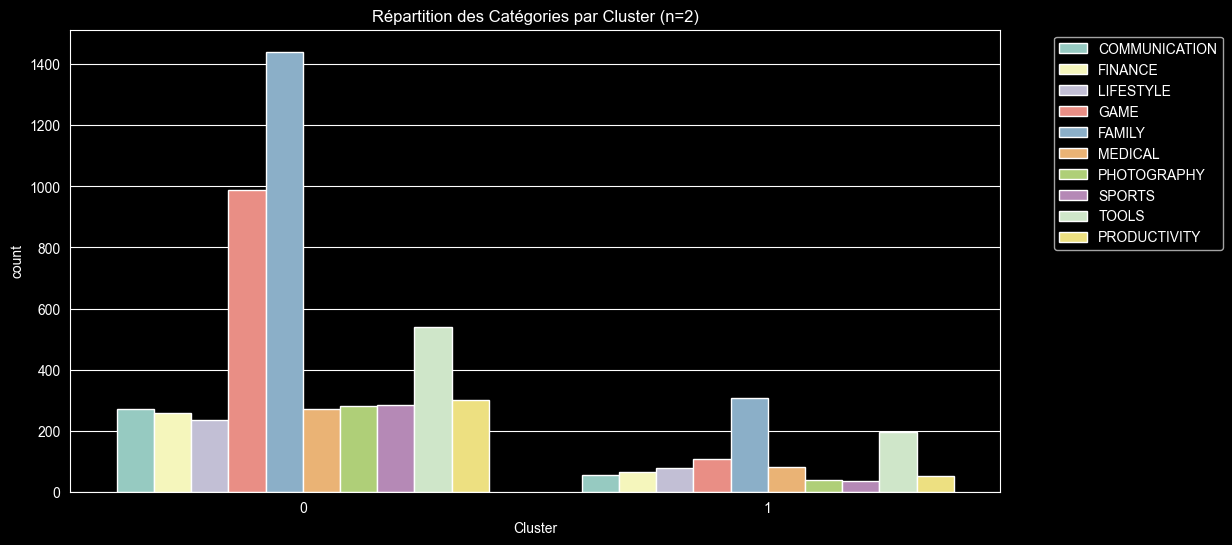

----> PCA


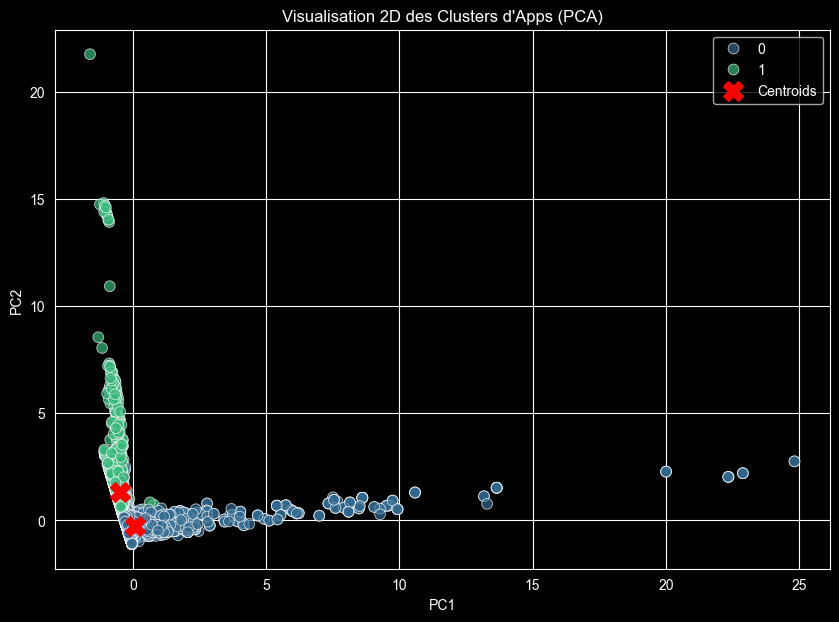

------- 3 CLUSTERS -------
Distance Moyenne: 0.9283


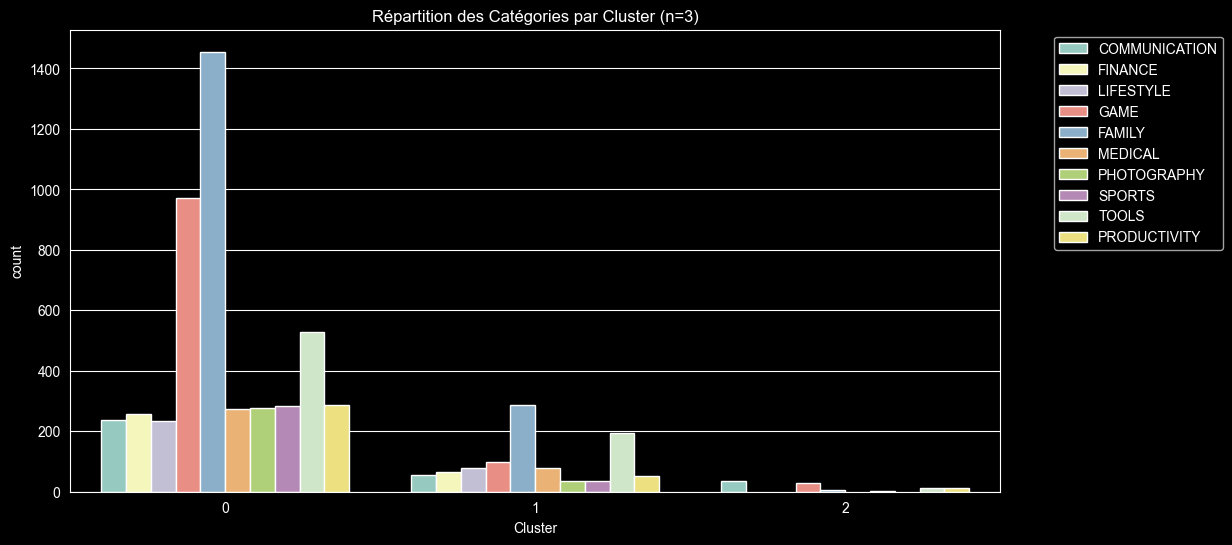

----> PCA


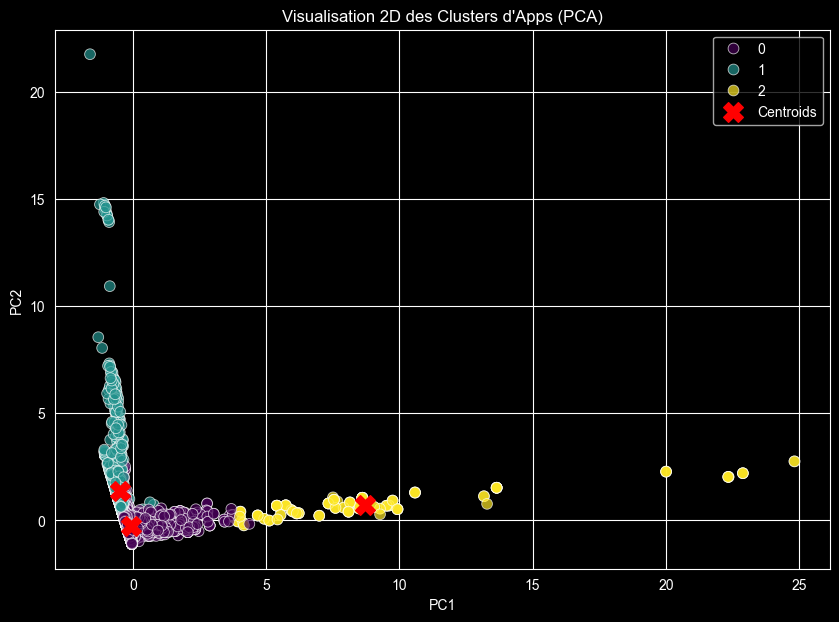

------- 4 CLUSTERS -------
Distance Moyenne: 0.8872


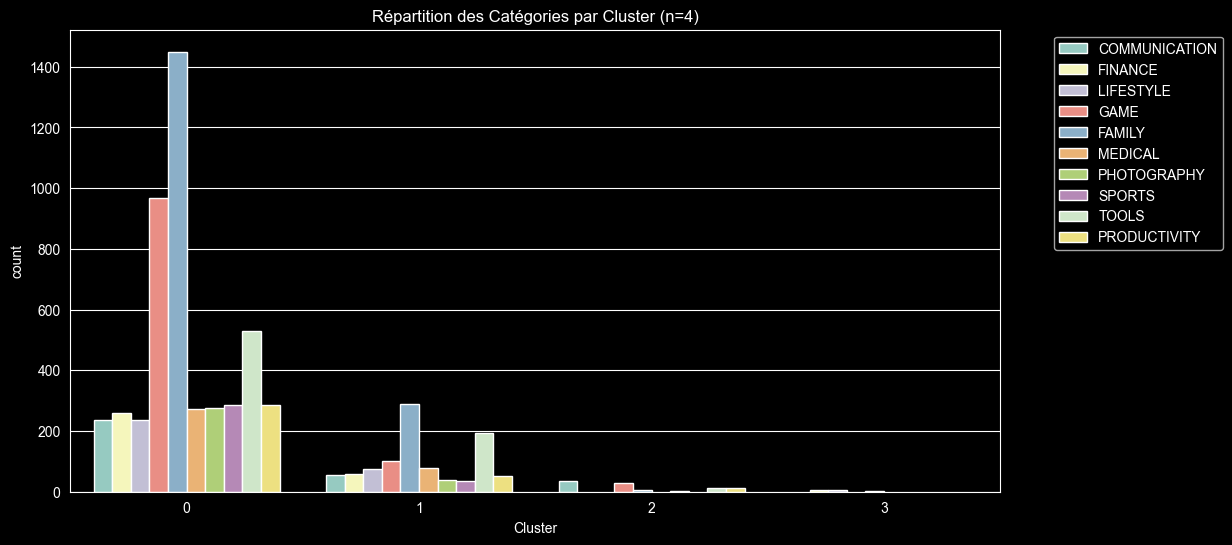

----> PCA


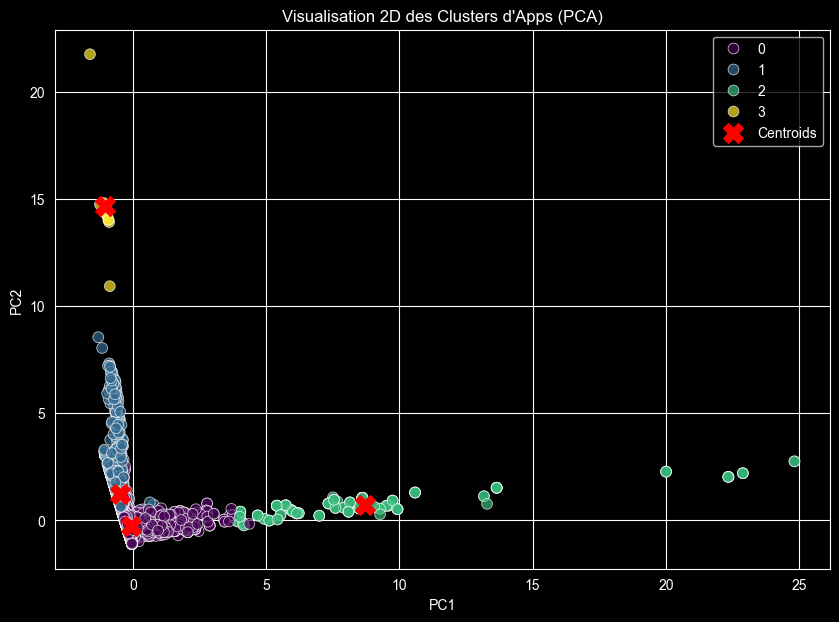

------- 5 CLUSTERS -------
Distance Moyenne: 0.7649


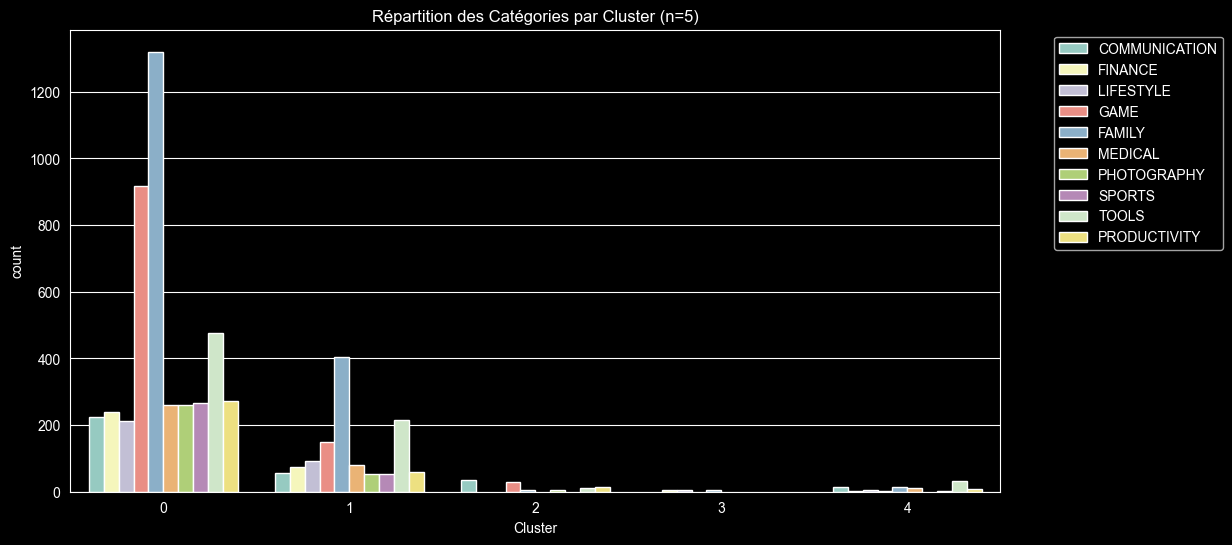

----> PCA


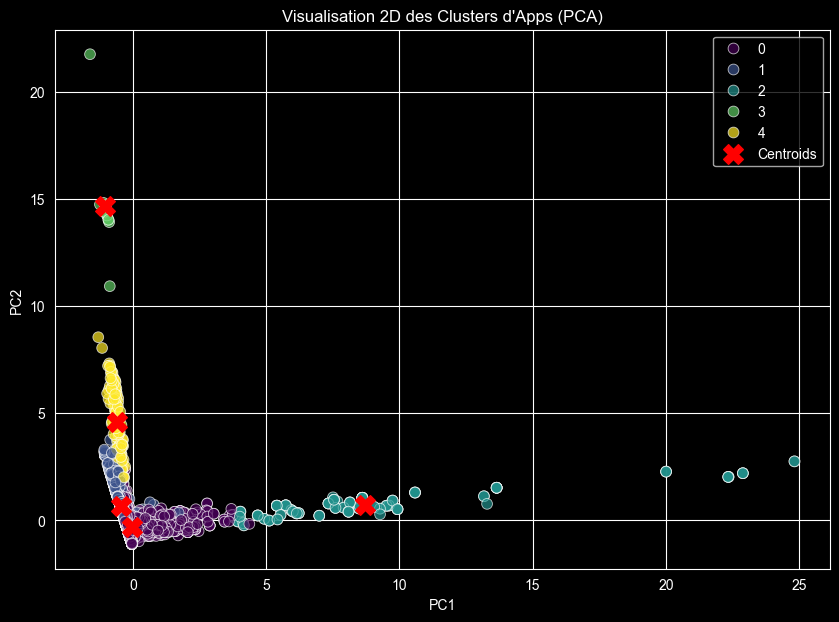

In [120]:
# TODO 5.4
from sklearn.decomposition import PCA

clusters = [2, 3, 4, 5]

for x in clusters:
    print(f"------- {x} CLUSTERS -------")
    km = KMeans(n_clusters=x, max_iter=15, random_state=42, n_init=1).fit(df_s)
    avg_dist = average_cluster_distance(df_s, km)[0]
    results.append(avg_dist)
    print(f"Distance Moyenne: {avg_dist:.4f}")
    
    df_5['Cluster'] = km.labels_

    plt.figure(figsize=(12, 6))
    top_categories = df_5['Category'].value_counts().nlargest(10).index
    df_plot = df_5[df_5['Category'].isin(top_categories)]

    sns.countplot(data=df_plot, x='Cluster', hue='Category')
    plt.title(f"Répartition des Catégories par Cluster (n={x})")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
    
    print("----> PCA")
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(df_s)
    
    df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
    df_pca['Cluster'] = km.labels_
    
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='viridis', s=60, alpha=0.7)

    # Ajout des centres des clusters
    centers_pca = pca.transform(km.cluster_centers_)
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

    plt.title("Visualisation 2D des Clusters d'Apps (PCA)")
    plt.legend()
    plt.show()

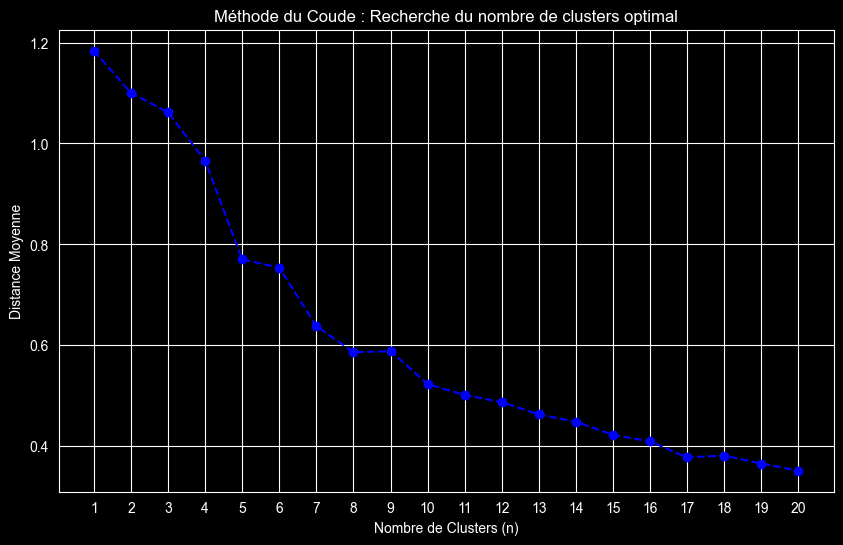

In [121]:
n_range = range(1, 21)
distances = []

for n in n_range:
    km = KMeans(n_clusters=n, max_iter=15, random_state=42, n_init=10).fit(df_s)
    avg_dist = average_cluster_distance(df_s, km)[0]
    distances.append(avg_dist)
    
plt.figure(figsize=(10, 6))
plt.plot(n_range, distances, marker='o', linestyle='--', color='b')
plt.xlabel('Nombre de Clusters (n)')
plt.ylabel('Distance Moyenne')
plt.title('Méthode du Coude : Recherche du nombre de clusters optimal')
plt.xticks(n_range)
plt.grid(True)
plt.show()

Nous pouvons observer dans les différents graphiques, que nous avons générés, c'est que plus, on augmente le nombre de clusters la distance diminue. Mais les premiers clusters possèdent beaucoup plus d'apps contrairement au reste, cela est confirmé quand on affiche la répartition des apps avec PCA, les apps ont très agglutiné a un endroit et il y a quelque app un peu excentré.

Pour 5 clusters :

Cluster 0 : C'est le cluster "généraliste". Il contient le plus grand volume d'applications, avec une domination massive des catégories FAMILY et GAME. Ce sont probablement des applications avec un nombre d'installations et de reviews "standard" pour le marché.
Cluster 1 : Il semble être une version plus réduite du Cluster 0, agissant comme un second groupe de densité.
Le Cluster 2 pourrait regrouper les "Mega-Apps" (celles qui ont des milliards d'installations comme Facebook ou WhatsApp).
Le Cluster 3 ou 4 pourrait isoler les applications les plus chères du store ou celles ayant une taille (Size) gigantesque (family tools (souvent des apps chère, )).
Le fait que ces clusters soient quasi vides sur le graphique de comptage confirme la structure en "L" vue sur ta PCA : une immense masse de points à l'origine et quelques points isolés très loin sur les axes.